In [1]:
import pathlib
import json
import re
import os

from IPython.display import display
import matplotlib.pyplot
import numpy
import polars
from tqdm.notebook import tqdm

EVALUATION_DIR = pathlib.Path.cwd() / "06_1evaluation"
os.environ["EVALUATION_DIR"] = str(EVALUATION_DIR)

In [2]:
fcps = []
jsons = list((EVALUATION_DIR / "output-dataset").glob("lighthouse-run-*.report.json"))

for json_report in tqdm(jsons):
    with open(json_report) as json_file:
        obj = json.load(json_file)
        try:
            fcp = obj["audits"]["first-contentful-paint"]["numericValue"]
            error = None
        except KeyError:
            fcp = None
            error = obj["runtimeError"]["code"]

            if error == "ERRORED_DOCUMENT_REQUEST":
                match = re.search(r"Status code: (\d+)", obj["runtimeError"]["message"])
                error = f"{error} (Status: {match[1]})"
        if not error:
            lcp = obj["audits"]["largest-contentful-paint"].get("numericValue")
            speed_index = obj["audits"]["speed-index"].get("numericValue")
            total_blocking_time = obj["audits"]["total-blocking-time"].get("numericValue")
            cumulative_layout_shift = obj["audits"]["cumulative-layout-shift"].get("numericValue")
        else:
            lcp = None
            speed_index = None
            total_blocking_time = None
            cumulative_layout_shift = None
        match = re.match(r"lighthouse-run-(?P<domain>.*)-(?P<run>\d{3})-(?P<compress>true|false)-(?P<packed>true|false)-(?P<lhts>\d+)\.report\.json", json_report.name)
        
        res = match.groupdict()
        res["run"] = int(res["run"])
        res["compress"] = res["compress"] == "true"
        res["packed"] = res["packed"] == "true"
        res["lhts"] = int(res["lhts"])
        res["fcp"] = fcp
        res["lcp"] = lcp
        res["speed_index"] = speed_index
        res["total_blocking_time"] = total_blocking_time
        res["cumulative_layout_shift"] = cumulative_layout_shift
        res["error"] = error
        res["filename"] = json_report.name
        fcps.append(res)

df = polars.DataFrame(fcps).rename(
    {
        "lhts": "lighthouse_timestamp",
        "fcp": "first_contentful_paint",
        "lcp": "largest_contentful_paint",
    }
)
df.write_parquet(EVALUATION_DIR / "output-dataset" / "lighthouse.parquet")

  0%|          | 0/606 [00:00<?, ?it/s]

60 2.783333333333333
12186.170200000002
12198.937


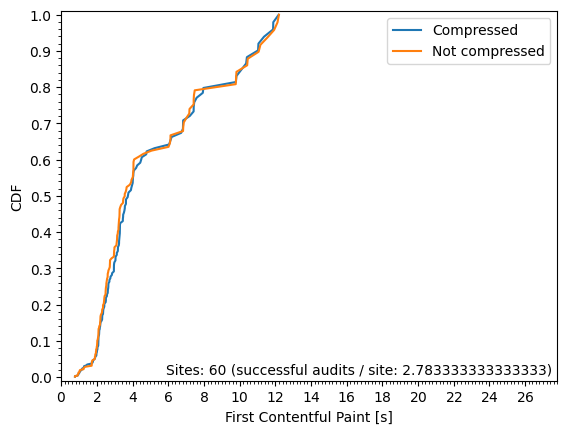

60 2.783333333333333
26390.694500000005
26553.849000000002


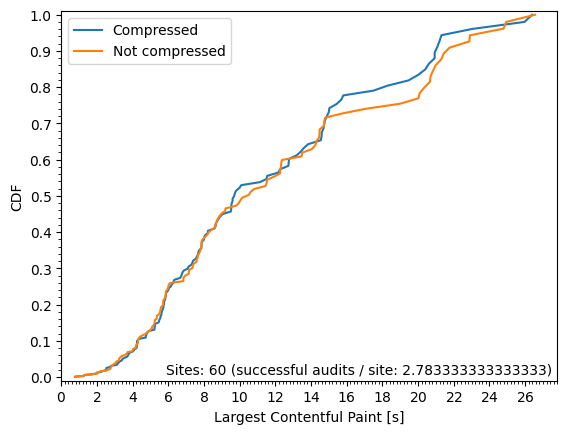

60 2.783333333333333
27504.432061984888
20251.257101564916


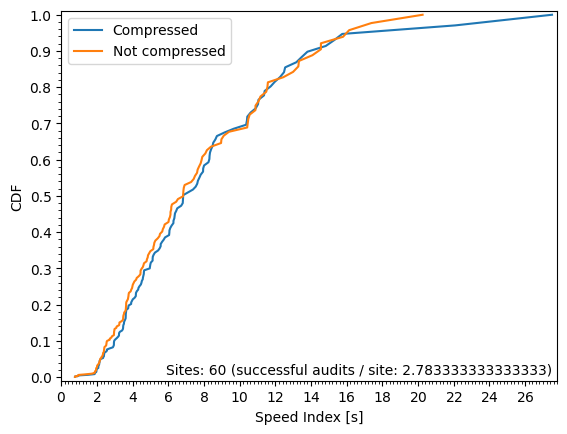

60 2.783333333333333
5600.0
3472.0


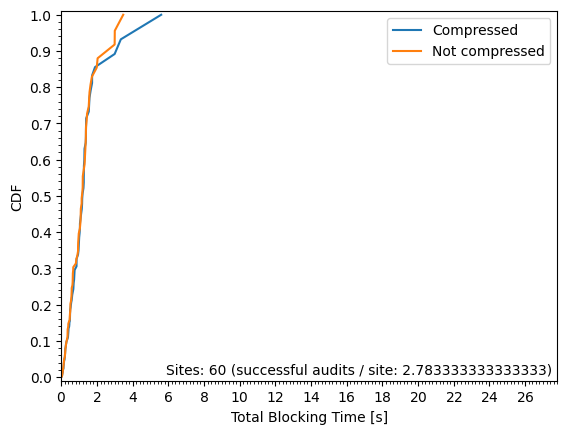

In [3]:
df = polars.read_parquet(EVALUATION_DIR / "output-dataset" / "lighthouse.parquet")

for metric in ["first_contentful_paint", "largest_contentful_paint", "speed_index", "total_blocking_time"]:
    times = df.filter(~polars.col("packed")).select(
        ["compress", "domain", "run", metric]
    ).pivot(
        "compress",
        index=["domain", "run"],
        values=[metric]
    ).filter(
        polars.col("true").is_not_null()
        & polars.col("false").is_not_null()
    ).rename(
        {
            "true": "Compressed",
            "false": "Not compressed",
        }
    )
    domains = times.select(polars.col("domain").unique()).shape[0]
    audits = times.shape[0]
    print(domains, audits / domains)
    matplotlib.pyplot.clf()
    ax = matplotlib.pyplot.gca()
    
    for comp in ["Compressed", "Not compressed"]:
        cdf = times.select([comp]).sort(comp).with_columns(
            cdf=polars.first().cum_sum() / polars.first().sum()
        ).rename({comp: metric})
        ax.plot(cdf[metric], cdf["cdf"], label=comp)
        print(cdf[metric].max())
    ax.set_xlabel(f"{metric.replace("_", " ").title()} [s]")
    ax.set_xlim(0, 27800)
    ax.set_xticks(numpy.arange(0, 28000, 2000))
    ax.set_xticks(numpy.arange(0, 27900, 200), minor=True)
    ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x / 1000.0:.0f}$"))
    ax.set_ylabel("CDF")
    ax.set_ylim(-0.01, 1.01)
    ax.set_yticks(numpy.arange(0, 1.1, 0.1))
    ax.set_yticks(numpy.arange(0, 1.01, 0.02), minor=True)
    ax.text(
        0.99,
        0.01,
        f"Sites: {domains} (successful audits / site: {audits / domains})", 
        ha="right",
        va="bottom",
        transform=ax.transAxes,
    )
    ax.legend()
    matplotlib.pyplot.show()